In [25]:
# 1. Collaborative Filtering -> Similar users get similar recommendations
# e.g: If P1 buys an iPhone + ear phones, and P2 buys an iPhone as well, ear phones are recommended to P2

In [26]:
# 2. Content Based Filtering -> Similar items get similar recommendations
# e.g: If P1 has rated an iPhone highly, similar phones are suggested to P1

In [27]:
# 3. Hybrid Filtering -> Combination of both collaborative and content based filtering
# e.g: takes an avg between the two methods to recommend items

In [28]:
import pandas as pd
import numpy as np
import os

In [ ]:
data_path = os.path.join(os.getcwd(), 'data', 'content based')

In [30]:
column_names = ['user_id', 'movie_id', 'rating', 'timestamp']
ratings = pd.read_csv(os.path.join(data_path, 'u.data'), sep='\t', names=column_names)
ratings.drop('timestamp', axis=1, inplace=True)
ratings.head(10)

,user_id,movie_id,rating
0,0,50,5
1,0,172,5
2,0,133,1
3,196,242,3
4,186,302,3
5,22,377,1
6,244,51,2
7,166,346,1
8,298,474,4
9,115,265,2


In [31]:
titles = pd.read_csv(os.path.join(data_path, 'Movie_Id_Titles.txt'))
titles.rename(columns={'item_id': 'movie_id'}, inplace=True)
titles.head(10)

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)
5,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...
6,7,Twelve Monkeys (1995)
7,8,Babe (1995)
8,9,Dead Man Walking (1995)
9,10,Richard III (1995)


In [32]:
merged = pd.merge(ratings, titles, on='movie_id', how='left').reset_index(drop=True)
merged.head(10)

,user_id,movie_id,rating,title
0,0,50,5,Star Wars (1977)
1,0,172,5,"Empire Strikes Back, The (1980)"
2,0,133,1,Gone with the Wind (1939)
3,196,242,3,Kolya (1996)
4,186,302,3,L.A. Confidential (1997)
5,22,377,1,Heavyweights (1994)
6,244,51,2,Legends of the Fall (1994)
7,166,346,1,Jackie Brown (1997)
8,298,474,4,Dr. Strangelove or: How I Learned to Stop Worr...
9,115,265,2,"Hunt for Red October, The (1990)"


In [33]:
count_rating = merged.groupby('title')['rating'].count().reset_index().rename(columns={'rating': 'num_ratings'}).sort_values(by='num_ratings', ascending=False)
count_rating.head(10)

,title,num_ratings
1398,Star Wars (1977),584
333,Contact (1997),509
498,Fargo (1996),508
1234,Return of the Jedi (1983),507
860,Liar Liar (1997),485
460,"English Patient, The (1996)",481
1284,Scream (1996),478
1523,Toy Story (1995),452
32,Air Force One (1997),431
744,Independence Day (ID4) (1996),429


In [34]:
merged_count_rating = pd.merge(merged, count_rating, on='title', how='left')
merged_count_rating.head(10)

,user_id,movie_id,rating,title,num_ratings
0,0,50,5,Star Wars (1977),584
1,0,172,5,"Empire Strikes Back, The (1980)",368
2,0,133,1,Gone with the Wind (1939),172
3,196,242,3,Kolya (1996),117
4,186,302,3,L.A. Confidential (1997),297
5,22,377,1,Heavyweights (1994),13
6,244,51,2,Legends of the Fall (1994),81
7,166,346,1,Jackie Brown (1997),126
8,298,474,4,Dr. Strangelove or: How I Learned to Stop Worr...,194
9,115,265,2,"Hunt for Red October, The (1990)",227


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

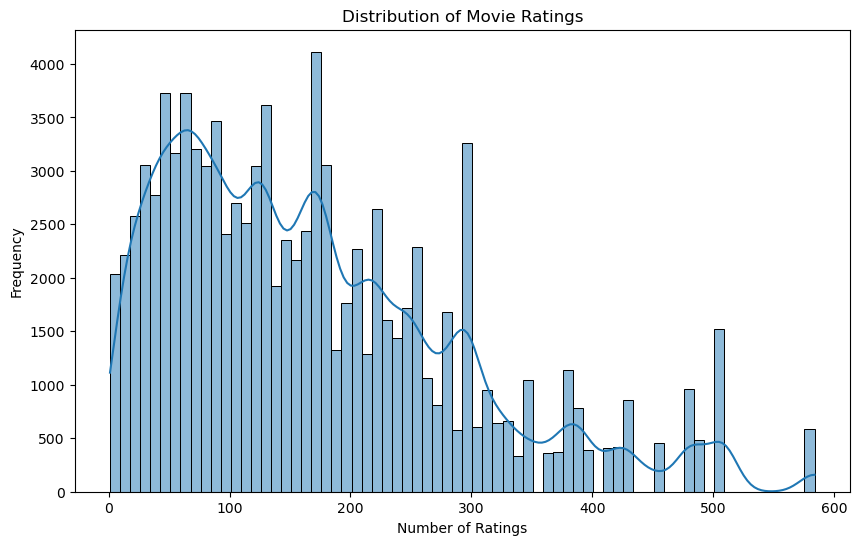

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_count_rating['num_ratings'], bins=70, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.show()

In [37]:
rating_threshold = 100
popular_movies = merged_count_rating.query('num_ratings >= @rating_threshold')
popular_movies.head(10)

,user_id,movie_id,rating,title,num_ratings
0,0,50,5,Star Wars (1977),584
1,0,172,5,"Empire Strikes Back, The (1980)",368
2,0,133,1,Gone with the Wind (1939),172
3,196,242,3,Kolya (1996),117
4,186,302,3,L.A. Confidential (1997),297
7,166,346,1,Jackie Brown (1997),126
8,298,474,4,Dr. Strangelove or: How I Learned to Stop Worr...,194
9,115,265,2,"Hunt for Red October, The (1990)",227
11,305,451,3,Grease (1978),170
12,6,86,3,"Remains of the Day, The (1993)",150


In [38]:
movie_features = popular_movies.pivot_table(index='title', columns='user_id', values='rating', fill_value=0)
movie_features.head(10)

user_id,0,1,2,3,4,5,6,7,8,9,...,934,935,936,937,938,939,940,941,942,943
title,,,,,,,,,,,,,,,,,,,,,
101 Dalmatians (1996),0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0
12 Angry Men (1957),0.0,5.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001: A Space Odyssey (1968),0.0,4.0,0.0,0.0,0.0,4.0,5.0,5.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
Absolute Power (1997),0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
"Abyss, The (1989)",0.0,3.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
Ace Ventura: Pet Detective (1994),0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
"Adventures of Priscilla, Queen of the Desert, The (1994)",0.0,0.0,0.0,0.0,0.0,5.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0
"African Queen, The (1951)",0.0,0.0,0.0,0.0,0.0,0.0,4.0,5.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
Air Force One (1997),0.0,0.0,4.0,2.0,5.0,0.0,0.0,4.0,0.0,0.0,...,0.0,4.0,3.0,4.0,3.0,0.0,5.0,4.0,5.0,0.0


In [39]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

In [40]:
feature_matrix = csr_matrix(movie_features.values)

knn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=10, n_jobs=-1)
knn_model.fit(feature_matrix)

NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1, n_neighbors=10)

In [41]:
random_movie = np.random.choice(movie_features.index)
print(f"Randomly selected movie: {random_movie}")
distances, indices = knn_model.kneighbors(movie_features.loc[random_movie].values.reshape(1, -1), n_neighbors=10)
for i in range(len(distances.flatten())):
    if i == 0:
        print(f"Recommendations for {random_movie}:\n")
    else:
        movie_title = movie_features.index[indices.flatten()[i]]
        print(f"{i}: {movie_title} (Distance: {distances.flatten()[i]:.4f})")
print("Note: Distances are in cosine similarity metric, lower values indicate more similar movies")

Randomly selected movie: Back to the Future (1985)
Recommendations for Back to the Future (1985):

1: Indiana Jones and the Last Crusade (1989) (Distance: 0.2298)
2: Raiders of the Lost Ark (1981) (Distance: 0.2304)
3: Empire Strikes Back, The (1980) (Distance: 0.2465)
4: Groundhog Day (1993) (Distance: 0.2663)
5: Monty Python and the Holy Grail (1974) (Distance: 0.2715)
6: Forrest Gump (1994) (Distance: 0.2815)
7: E.T. the Extra-Terrestrial (1982) (Distance: 0.2907)
8: Terminator, The (1984) (Distance: 0.3039)
9: When Harry Met Sally... (1989) (Distance: 0.3044)
Note: Distances are in cosine similarity metric, lower values indicate more similar movies
